In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shambhurajejagadale/student-performance-prediction-dataset/student_dataset_10000_rows.csv


In [2]:
df=pd.read_csv("/kaggle/input/datasets/shambhurajejagadale/student-performance-prediction-dataset/student_dataset_10000_rows.csv")
df

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed
...,...,...,...,...,...,...,...,...
9995,2,58,9,7,8,88,69.31,Not Placed
9996,7,98,6,9,4,87,100.00,Placed
9997,10,44,8,5,10,37,95.94,Placed
9998,10,75,7,5,8,52,88.61,Placed


In [3]:

df.isnull().sum()
df.info()
df.describe()
df.duplicated().sum()
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            10000 non-null  int64  
 1   attendance             10000 non-null  int64  
 2   sleep_hours            10000 non-null  int64  
 3   internet_usage         10000 non-null  int64  
 4   assignments_completed  10000 non-null  int64  
 5   previous_score         10000 non-null  int64  
 6   exam_score             10000 non-null  float64
 7   placement_status       10000 non-null  object 
dtypes: float64(1), int64(6), object(1)
memory usage: 625.1+ KB


,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed
...,...,...,...,...,...,...,...,...
9995,2,58,9,7,8,88,69.31,Not Placed
9996,7,98,6,9,4,87,100.00,Placed
9997,10,44,8,5,10,37,95.94,Placed
9998,10,75,7,5,8,52,88.61,Placed


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# ***Checking Features and their correlation with placement***

***Ans:-There is strong correlation between exam scores and placement as compared to study hours***

<Axes: xlabel='study_hours', ylabel='exam_score'>

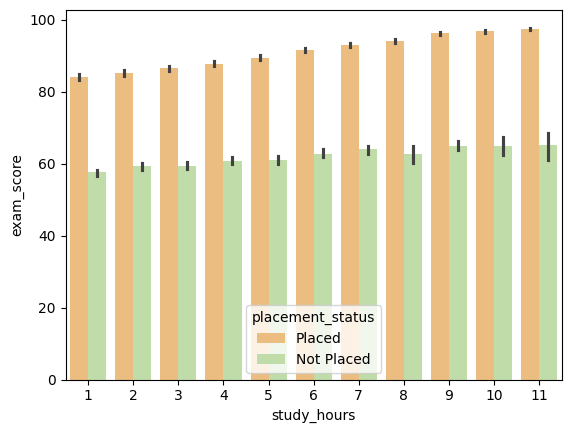

In [5]:
sns.barplot(x=df["study_hours"],y=df["exam_score"], palette="Spectral",hue=df["placement_status"])

# ***Does Study Hours Affect Placement?***

***Ans:- According to our data yes study hour has strong correlation with placements....***

<Axes: xlabel='placement_status', ylabel='study_hours'>

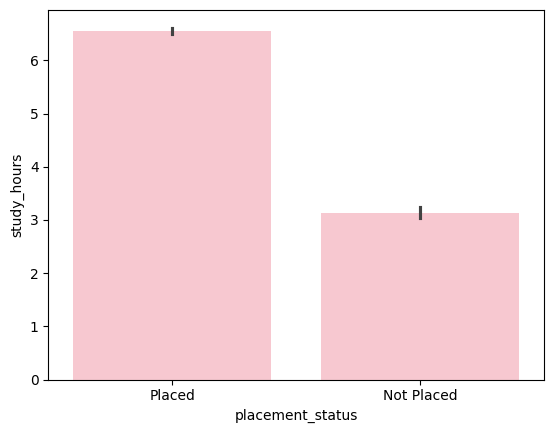

In [6]:
sns.barplot(x=df["placement_status"],y=df["study_hours"],color="pink")

<Axes: xlabel='sleep_hours', ylabel='exam_score'>

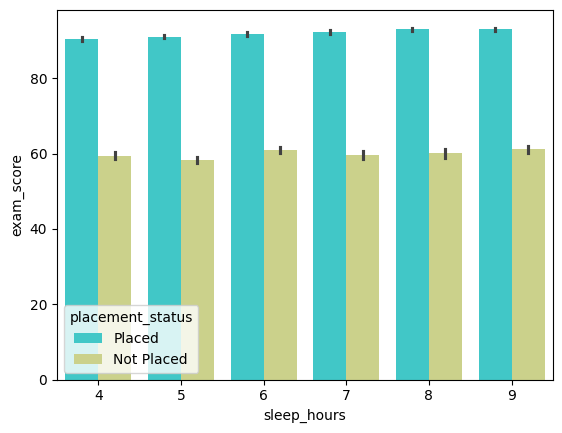

In [7]:
sns.barplot(x=df["sleep_hours"],y=df["exam_score"], palette="rainbow",hue=df["placement_status"])

# ***Checking Correlation between features***

***POV:- It is is guess an AI generated dataset used for practice purpose as it is showing negative correlation between assignments conpletion and attendance while in real world they heavily relies on each others***

<Axes: >

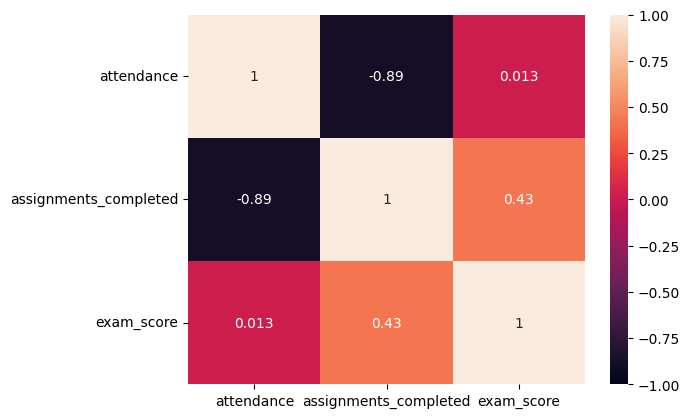

In [8]:
columns=df[["attendance","assignments_completed","exam_score"]].head()
corr_cols=columns.corr()
sns.heatmap(corr_cols,annot=True,vmin=-1,vmax=1)

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

In [10]:
le=LabelEncoder()
df["placement_status"]=le.fit_transform(df["placement_status"])
df["placement_status"]

0       1
1       1
2       1
3       1
4       1
       ..
9995    0
9996    1
9997    1
9998    1
9999    1
Name: placement_status, Length: 10000, dtype: int64

# ***Best features Selection***
***Since there aren't many columns so we will check best columns that have high correlation with placement offer and then select them as features***

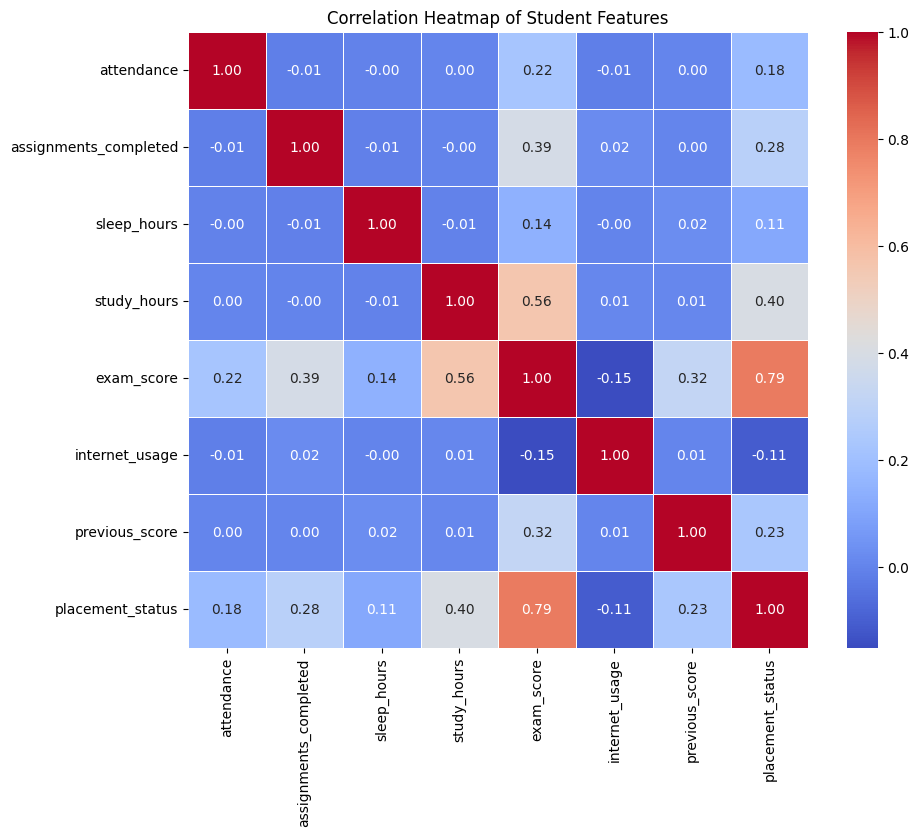

In [11]:
# First we will Calculate the correlation matrix for 8 columns
corr_matrix = df[['attendance', 'assignments_completed', 'sleep_hours', 'study_hours', 'exam_score', 'internet_usage', 'previous_score', 'placement_status']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Student Features')
plt.show()

***Key insight is that all of them have weak correlation with placement_status which we are going to predict except for exam score so we will use all of them except internet usage as it has negative correlation with placement and all can work low but still it is just an AI generated Data set so it contains this type of issue i guess***

In [12]:
cols=["previous_score","attendance","study_hours","assignments_completed","sleep_hours"]
X=df[cols]
y=df["placement_status"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=100)



model=LogisticRegression()
model.fit(X_train,y_train)
y_predict=model.predict(X_test)
result=classification_report(y_test,y_predict)
print(f"The Classification Report is {result}")


The Classification Report is               precision    recall  f1-score   support

           0       0.74      0.60      0.66       320
           1       0.93      0.96      0.94      1680

    accuracy                           0.90      2000
   macro avg       0.83      0.78      0.80      2000
weighted avg       0.90      0.90      0.90      2000



***Conclusion: > Initially, including exam_score led to an unrealistic 100% accuracy due to target leakage (the synthetic dataset relied entirely on the exam score to decide placement). After dropping exam_score and training the model purely on behavioral indicators (attendance, study hours, assignments, sleep), the model achieved a realistic and strong 90% classification accuracy.***

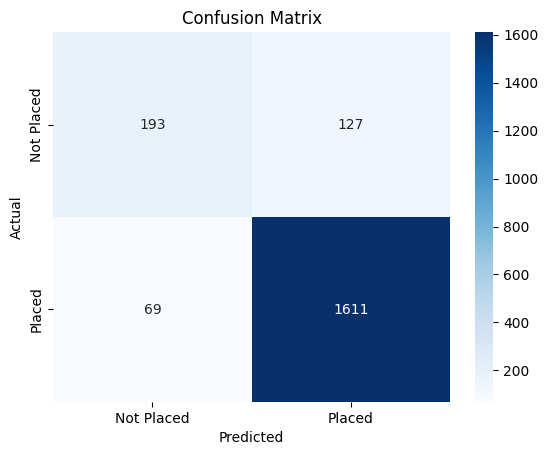

In [13]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Generate and plot the confusion matrix
cm = confusion_matrix(y_test, y_predict)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Placed', 'Placed'], 
            yticklabels=['Not Placed', 'Placed'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()


# ***Optinal Step to check how many right or wrong predictions our Model did***


# ***1.The Correct Predictions (The Diagonal):-***

***The dark blue and light blue squares along the main diagonal are the ones our   model got right:***

***True Negatives (193): The model correctly predicted 193 students as "Not Placed" who were actually not placed.***

***True Positives (1611): The model correctly predicted 1611 students as "Placed" who were actually placed. (This dark blue block shows that our model is exceptionally strong at identifying successful placements).***

# ***2. The Errors (The Off-Diagonal):-***

***The white/light squares are your model's errors:
False Positives (127): The model predicted 127 students would be "Placed", but they actually were "Not Placed".***


***False Negatives (69): The model predicted 69 students would be "Not Placed", but they actually managed to get "Placed".***


***What this tells you about your dataset
Because our dataset is imbalanced (there are far more placed students than unplaced ones—1680 vs 320 in the test set),so our model has naturally become much better at recognizing what a "Placed" student looks like.***

***Missing 127 students out of 320 unplaced ones explains why our unplaced recall was lower (0.60), while getting 1611 out of 1680 placed ones right explains our high placed recall (0.96).***

In [14]:
import pickle

# Save the trained model object to a local file
with open('logistic_placement_model.pkl', 'wb') as file:
    pickle.dump(model, file)
    